<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Nuclear_Stability_Evidence_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# ECSM Nuclear Stability Evidence Notebook

**Testing finite-response closure predictors against isotope-valley and beta-decay data**

This notebook supports the paper:

> *Nuclear Stability as Finite-Response Closure in the ECSM Framework: Mirror Branches, Triadic Stabilisation, Alpha Closure, and the Isotope Valley*  
> Adam M. Sheldrick, 2026. Zenodo DOI: https://doi.org/10.5281/zenodo.20601314

## Aim

The conceptual paper proposes:

> **Nuclear stability is finite-response closure. Radioactive decay is finite-response relaxation.**

This notebook turns that claim into first quantitative tests:

1. Load public nuclear ground-state data from the IAEA LiveChart API when online.
2. Build isotope features from \(Z,N,A\): mirror imbalance, Coulomb burden proxy, pairing, shell/magic closure, alpha closure, and response-saturation proxies.
3. Fit a deliberately simple ECSM-style stability score.
4. Test whether the score recovers stable-isotope structure and beta-decay direction.
5. Export tables and figures for GitHub / Zenodo / paper support.

## Data source

Primary loader: IAEA LiveChart `ground_states` CSV API. The API guide states that `fields=ground_states&nuclides=all` returns all ground states, including half-life and up to three decay modes. If the notebook is run offline, it falls back to an embedded sanity dataset covering the light-nucleus ladder and several anchor nuclei; this fallback is for code verification only, not for final evidence claims.


In [10]:

# ============================================================
# CELL 01 — Imports and notebook configuration
# ============================================================
from __future__ import annotations

import io
import json
import math
import os
import re
import urllib.request
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

pd.set_option('display.max_columns', 160)
pd.set_option('display.width', 180)

OUT = Path('ecsm_nuclear_stability_evidence_out')
FIG = OUT / 'figures'
TAB = OUT / 'tables'
for p in [OUT, FIG, TAB]:
    p.mkdir(parents=True, exist_ok=True)

IAEA_GROUND_STATES_URL = 'https://nds.iaea.org/relnsd/v1/data?fields=ground_states&nuclides=all'
FORCE_EMBEDDED_SAMPLE = False  # Set True for offline debugging / deterministic mini-run.
RANDOM_STATE = 42

print('Output directory:', OUT.resolve())


Output directory: /content/ecsm_nuclear_stability_evidence_out


In [11]:

# ============================================================
# CELL 02 — Robust data loader: IAEA LiveChart + embedded sanity fallback
# ============================================================

def read_iaea_ground_states(url: str = IAEA_GROUND_STATES_URL, timeout: int = 5) -> pd.DataFrame:
    '''Read the IAEA LiveChart ground-state CSV with a user-agent header.

    The IAEA guide notes that some calls can return 403 unless a user-agent is supplied.
    '''
    req = urllib.request.Request(url)
    req.add_header('User-Agent', 'Mozilla/5.0 (X11; Linux x86_64) ECSM-evidence-notebook/1.0')
    with urllib.request.urlopen(req, timeout=timeout) as response:
        raw = response.read()
    # IAEA returns CSV text. Let pandas infer separators and types, preserving strings where needed.
    return pd.read_csv(io.BytesIO(raw))


def embedded_sanity_dataset() -> pd.DataFrame:
    '''Small offline dataset for pipeline verification only.

    This is NOT a substitute for LiveChart/NUBASE/AME data. It covers the conceptual ladder:
    D, T -> He-3, He-4, N≈Z anchors, neutron-rich heavy anchors, and simple beta mirror cases.
    '''
    rows = [
        # symbol, Z, N, A, half_life, unit_hl, decay_1, binding_per_A_MeV, notes
        ('H',  1,   0,   1, 'STABLE', '',   '',      0.000,  'proton anchor'),
        ('H',  1,   1,   2, 'STABLE', '',   '',      1.112,  'deuterium: weakly bound bipolar bridge'),
        ('H',  1,   2,   3, '12.32',  'y',  'B-',    2.827,  'tritium beta-minus to helium-3'),
        ('He', 2,   1,   3, 'STABLE', '',   '',      2.573,  'helium-3 mirror triad'),
        ('He', 2,   2,   4, 'STABLE', '',   '',      7.074,  'helium-4 alpha closure'),
        ('C',  6,   6,  12, 'STABLE', '',   '',      7.680,  'N=Z alpha-like anchor'),
        ('C',  6,   8,  14, '5730',   'y',  'B-',    7.520,  'beta-minus neutron-rich'),
        ('O',  8,   6,  14, '70.6',   's',  'B+ EC', 7.052,  'proton-rich mirror branch'),
        ('O',  8,   8,  16, 'STABLE', '',   '',      7.976,  'N=Z closure'),
        ('Ca', 20, 20,  40, 'STABLE', '',   '',      8.551,  'N=Z doubly magic-ish anchor'),
        ('Fe', 26, 30,  56, 'STABLE', '',   '',      8.790,  'iron peak region'),
        ('Ni', 28, 34,  62, 'STABLE', '',   '',      8.795,  'nickel binding peak anchor'),
        ('Pb', 82,126, 208, 'STABLE', '',   '',      7.867,  'heavy neutron compensation'),
        ('U',  92,146, 238, '4.468e9','y',  'A',     7.570,  'alpha decay heavy anchor'),
    ]
    df = pd.DataFrame(rows, columns=['symbol','z','n','a','half_life','unit_hl','decay_1','binding_per_A_MeV','notes'])
    df['source'] = 'embedded_sanity_fallback'
    return df

if FORCE_EMBEDDED_SAMPLE:
    raw = embedded_sanity_dataset()
    DATA_SOURCE = 'embedded_sanity_fallback_forced'
else:
    try:
        raw = read_iaea_ground_states()
        raw['source'] = 'IAEA_LiveChart_ground_states'
        DATA_SOURCE = 'IAEA_LiveChart_ground_states'
    except Exception as exc:
        print('Live download failed; using embedded sanity dataset only.')
        print('Download error:', repr(exc))
        raw = embedded_sanity_dataset()
        DATA_SOURCE = 'embedded_sanity_fallback_download_failed'

print('DATA_SOURCE =', DATA_SOURCE)
print('raw shape:', raw.shape)
display(raw.head())
raw.to_csv(TAB / 'raw_ground_states_or_sanity.csv', index=False)


DATA_SOURCE = IAEA_LiveChart_ground_states
raw shape: (3386, 56)


,z,n,symbol,radius,unc_r,abundance,unc_a,energy_shift,energy,unc_e,ripl_shift,jp,half_life,operator_hl,unc_hl,unit_hl,half_life_sec,unc_hls,decay_1,decay_1_%,unc_1,decay_2,decay_2_%,unc_2,decay_3,decay_3_%,unc_3,isospin,magnetic_dipole,unc_md,electric_quadrupole,unc_eq,qbm,unc_qb,qbm_n,unc_qbmn,qa,unc_qa,qec,unc_qec,sn,unc_sn,sp,unc_sp,binding,unc_ba,atomic_mass,unc_am,massexcess,unc_me,me_systematics,discovery,ENSDFpublicationcut-off,ENSDFauthors,Extraction_date,source
0,0,1,n,-0.1149,0.0027,NaN,NaN,NaN,0.0,NaN,NaN,1/2+,613.9,NaN,6,s,6.139000e+02,0.6,B-,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.913043,5.000000e-07,NaN,NaN,782.347,0.0004,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,NaN,NaN,0.0000,0.0000,1.008665e+06,0.000470,8071.318060,0.000440,N,NaN,31-Oct-2005,BALRAJ SINGH,2023-10-18,IAEA_LiveChart_ground_states
1,0,4,n,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0+,2.6,LT,NaN,MeV,1.754760e-22,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30-Aug-2017,J.E. Purcell and C.G. Sheu,2023-10-18,IAEA_LiveChart_ground_states
2,0,6,n,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15-March-2017,J.H. Kelley and G.C. Sheu,2023-10-18,IAEA_LiveChart_ground_states
3,1,0,H,0.8783,0.0086,99.9855,0.0078,NaN,0.0,NaN,NaN,1/2+,STABLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.792847,9.000000e-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-782.347,0.0,NaN,NaN,0.0000,0.0000,0.0000,0.0000,1.007825e+06,0.000014,7288.971064,0.000013,N,1920.0,31-Oct-2005,BALRAJ SINGH,2023-10-18,IAEA_LiveChart_ground_states
4,1,1,H,2.1421,0.0088,0.0145,0.0078,NaN,0.0,NaN,NaN,1+,STABLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.857438,5.000000e-09,0.002858,3.000000e-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2224.5662,0.0004,2224.5662,0.0004,1112.2831,0.0002,2.014102e+06,0.000015,13135.722895,0.000015,N,1932.0,1-May-2003,J.H. KELLEY and J.L. GODWIN,2023-10-18,IAEA_LiveChart_ground_states


In [12]:

# ============================================================
# CELL 03 — Column audit and normalisation helpers
# ============================================================

def norm_col(c: str) -> str:
    c = str(c).strip().lower()
    c = c.replace(' ', '_').replace('-', '_').replace('/', '_')
    c = re.sub(r'[^a-z0-9_]+', '', c)
    c = re.sub(r'_+', '_', c).strip('_')
    return c

raw_norm = raw.copy()
raw_norm.columns = [norm_col(c) for c in raw_norm.columns]

print('Normalised columns:')
print(list(raw_norm.columns))

# Column finder with common aliases from LiveChart-like and fallback data.
def first_present(df: pd.DataFrame, aliases: Iterable[str]) -> Optional[str]:
    for a in aliases:
        aa = norm_col(a)
        if aa in df.columns:
            return aa
    return None

COL_Z = first_present(raw_norm, ['z','Z','protons','proton_number'])
COL_N = first_present(raw_norm, ['n','N','neutrons','neutron_number'])
COL_A = first_present(raw_norm, ['a','A','mass','mass_number'])
COL_SYMBOL = first_present(raw_norm, ['symbol','element','el','name'])
COL_HL = first_present(raw_norm, ['half_life','half-life','halflife','t12','t_1_2'])
COL_UNIT_HL = first_present(raw_norm, ['unit_hl','unit_half_life','half_life_unit','unit'])
DECAY_COLS = [c for c in raw_norm.columns if re.fullmatch(r'decay_[123]', c) or c in ['decay1','decay2','decay3','decay']]
BIND_COL = first_present(raw_norm, ['binding_per_A_MeV','binding_per_a_mev','binding_energy_per_a','binding_energy_per_nucleon','binding'])

print('Detected columns:')
print(json.dumps({
    'Z': COL_Z, 'N': COL_N, 'A': COL_A, 'symbol': COL_SYMBOL,
    'half_life': COL_HL, 'unit_hl': COL_UNIT_HL,
    'decay_cols': DECAY_COLS, 'binding_col': BIND_COL
}, indent=2))

if COL_Z is None or COL_N is None:
    raise ValueError('Could not detect Z and N columns. Inspect raw_norm.columns and add aliases above.')


Normalised columns:
['z', 'n', 'symbol', 'radius', 'unc_r', 'abundance', 'unc_a', 'energy_shift', 'energy', 'unc_e', 'ripl_shift', 'jp', 'half_life', 'operator_hl', 'unc_hl', 'unit_hl', 'half_life_sec', 'unc_hls', 'decay_1', 'decay_1', 'unc_1', 'decay_2', 'decay_2', 'unc_2', 'decay_3', 'decay_3', 'unc_3', 'isospin', 'magnetic_dipole', 'unc_md', 'electric_quadrupole', 'unc_eq', 'qbm', 'unc_qb', 'qbm_n', 'unc_qbmn', 'qa', 'unc_qa', 'qec', 'unc_qec', 'sn', 'unc_sn', 'sp', 'unc_sp', 'binding', 'unc_ba', 'atomic_mass', 'unc_am', 'massexcess', 'unc_me', 'me_systematics', 'discovery', 'ensdfpublicationcut_off', 'ensdfauthors', 'extraction_date', 'source']
Detected columns:
{
  "Z": "z",
  "N": "n",
  "A": null,
  "symbol": "symbol",
  "half_life": "half_life",
  "unit_hl": "unit_hl",
  "decay_cols": [
    "decay_1",
    "decay_1",
    "decay_2",
    "decay_2",
    "decay_3",
    "decay_3"
  ],
  "binding_col": "binding"
}


In [13]:
# ============================================================
# CELL 04 — Build canonical isotope table
# Robust against duplicate LiveChart columns after normalisation
# ============================================================

def pick_series(df: pd.DataFrame, col: str, default='') -> pd.Series:
    """
    Return a single Series even if df[col] returns multiple duplicate columns.
    Duplicate columns can happen after normalising LiveChart headers.
    """
    if col is None:
        return pd.Series([default] * len(df), index=df.index)

    obj = df[col]

    if isinstance(obj, pd.DataFrame):
        # Prefer the first non-empty value across duplicate columns.
        tmp = obj.copy()
        tmp = tmp.replace(['', ' ', 'nan', 'NaN', 'None', None], np.nan)
        return tmp.bfill(axis=1).iloc[:, 0].fillna(default)

    return obj.fillna(default)


def clean_text_series(s: pd.Series) -> pd.Series:
    return s.astype(str).replace(['nan', 'NaN', 'None'], '').str.strip()


def as_numeric_series(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors='coerce')


nu = pd.DataFrame(index=raw_norm.index)

# Core isotope identifiers
nu['Z'] = as_numeric_series(pick_series(raw_norm, COL_Z)).astype('Int64')
nu['N'] = as_numeric_series(pick_series(raw_norm, COL_N)).astype('Int64')

if COL_A is not None:
    nu['A'] = as_numeric_series(pick_series(raw_norm, COL_A)).astype('Int64')
else:
    nu['A'] = (nu['Z'] + nu['N']).astype('Int64')

if COL_SYMBOL is not None:
    nu['symbol'] = clean_text_series(pick_series(raw_norm, COL_SYMBOL))
else:
    nu['symbol'] = ''

nu['nuclide'] = nu['A'].astype(str) + nu['symbol'].astype(str)

# Half-life fields
if COL_HL:
    nu['half_life_raw'] = clean_text_series(pick_series(raw_norm, COL_HL))
else:
    nu['half_life_raw'] = ''

if COL_UNIT_HL:
    nu['half_life_unit'] = clean_text_series(pick_series(raw_norm, COL_UNIT_HL))
else:
    nu['half_life_unit'] = ''

# Decay fields — robust against duplicate decay columns
for i, c in enumerate(DECAY_COLS[:3], start=1):
    nu[f'decay_{i}'] = clean_text_series(pick_series(raw_norm, c))

for i in range(len(DECAY_COLS[:3]) + 1, 4):
    nu[f'decay_{i}'] = ''

nu['decay_all'] = (
    nu['decay_1'].fillna('') + ' ' +
    nu['decay_2'].fillna('') + ' ' +
    nu['decay_3'].fillna('')
).str.upper().str.strip()

# Binding energy if available
if BIND_COL is not None:
    nu['binding_per_A'] = as_numeric_series(pick_series(raw_norm, BIND_COL))
else:
    nu['binding_per_A'] = np.nan

nu['source'] = DATA_SOURCE

# Clean isotope rows
nu = nu.dropna(subset=['Z', 'N', 'A']).copy()
nu[['Z', 'N', 'A']] = nu[['Z', 'N', 'A']].astype(int)
nu = nu[(nu['Z'] >= 0) & (nu['N'] >= 0) & (nu['A'] > 0)].copy()
nu = nu.drop_duplicates(subset=['Z', 'N'], keep='first')

# Stability classification
stable_markers = ['STABLE', 'STBL', 'INF', 'INFINITY']

hl_text = (
    nu['half_life_raw'].fillna('') + ' ' +
    nu['half_life_unit'].fillna('')
).str.upper()

dec_text = nu['decay_all'].fillna('').str.upper()

nu['is_stable'] = hl_text.apply(lambda x: any(m in x for m in stable_markers))

# If an actual decay mode is present, override stable=False
has_decay_mode = dec_text.str.contains(
    r'B-|B\+|EC|ALPHA|A|IT|SF|P|N|2B|BETA',
    regex=True,
    na=False
)
nu.loc[has_decay_mode, 'is_stable'] = False

# Decay class
def classify_decay(s: str) -> str:
    s = str(s).upper().replace('β', 'B')
    if 'B-' in s or 'BETA-' in s:
        return 'beta_minus'
    if 'B+' in s or 'EC' in s or 'BETA+' in s:
        return 'beta_plus_or_EC'
    if 'ALPHA' in s or re.search(r'\bA\b', s):
        return 'alpha'
    if 'SF' in s:
        return 'spontaneous_fission'
    if s.strip() == '':
        return 'stable_or_unknown'
    return 'other_unstable'

nu['decay_class'] = nu['decay_all'].apply(classify_decay)
nu.loc[nu['is_stable'], 'decay_class'] = 'stable'

# Derived fields
nu['A_check'] = nu['Z'] + nu['N']
nu['N_over_Z'] = np.where(nu['Z'] > 0, nu['N'] / nu['Z'], np.nan)
nu['mirror_imbalance'] = nu['N'] - nu['Z']
nu['mirror_abs'] = np.abs(nu['mirror_imbalance'])
nu['is_N_eq_Z'] = nu['N'] == nu['Z']

print('Canonical isotope table:', nu.shape)
print(nu[['nuclide', 'Z', 'N', 'A', 'half_life_raw', 'half_life_unit', 'decay_all', 'is_stable', 'decay_class']].head(20))

display(nu.head(20))

nu.to_csv(TAB / 'canonical_isotope_table.csv', index=False)
print('Saved:', TAB / 'canonical_isotope_table.csv')

/tmp/ipykernel_738/4136375521.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return tmp.bfill(axis=1).iloc[:, 0].fillna(default)
/tmp/ipykernel_738/4136375521.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return tmp.bfill(axis=1).iloc[:, 0].fillna(default)
/tmp/ipykernel_738/4136375521.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcastin

Canonical isotope table: (3386, 20)
   nuclide  Z  N   A half_life_raw half_life_unit  decay_all  is_stable        decay_class
0       1n  0  1   1         613.9              s      B- B-      False         beta_minus
1       4n  0  4   4           2.6            MeV                 False  stable_or_unknown
2       6n  0  6   6                                              False  stable_or_unknown
3       1H  1  0   1        STABLE                                 True             stable
4       2H  1  1   2        STABLE                                 True             stable
5       3H  1  2   3         12.32              Y      B- B-      False         beta_minus
6       4H  1  3   4                                     N N      False     other_unstable
7       5H  1  4   5           5.3            MeV      2N 2N      False     other_unstable
8       6H  1  5   6          1.55            MeV                 False  stable_or_unknown
9       7H  1  6   7          0.09            MeV     

,Z,N,A,symbol,nuclide,half_life_raw,half_life_unit,decay_1,decay_2,decay_3,decay_all,binding_per_A,source,is_stable,decay_class,A_check,N_over_Z,mirror_imbalance,mirror_abs,is_N_eq_Z
0,0,1,1,n,1n,613.9,s,B-,B-,,B- B-,0.00000,IAEA_LiveChart_ground_states,False,beta_minus,1,NaN,1,1,False
1,0,4,4,n,4n,2.6,MeV,,,,,NaN,IAEA_LiveChart_ground_states,False,stable_or_unknown,4,NaN,4,4,False
2,0,6,6,n,6n,,,,,,,NaN,IAEA_LiveChart_ground_states,False,stable_or_unknown,6,NaN,6,6,False
3,1,0,1,H,1H,STABLE,,,,,,0.00000,IAEA_LiveChart_ground_states,True,stable,1,0.000000,-1,1,False
4,1,1,2,H,2H,STABLE,,,,,,1112.28310,IAEA_LiveChart_ground_states,True,stable,2,1.000000,0,0,True
5,1,2,3,H,3H,12.32,Y,B-,B-,,B- B-,2827.26540,IAEA_LiveChart_ground_states,False,beta_minus,3,2.000000,1,1,False
6,1,3,4,H,4H,,,N,N,,N N,1720.44910,IAEA_LiveChart_ground_states,False,other_unstable,4,3.000000,2,2,False
7,1,4,5,H,5H,5.3,MeV,2N,2N,,2N 2N,1336.35920,IAEA_LiveChart_ground_states,False,other_unstable,5,4.000000,3,3,False
8,1,5,6,H,6H,1.55,MeV,,,,,961.63950,IAEA_LiveChart_ground_states,False,stable_or_unknown,6,5.000000,4,4,False
9,1,6,7,H,7H,0.09,MeV,,,,,940.00000,IAEA_LiveChart_ground_states,False,stable_or_unknown,7,6.000000,5,5,False


Saved: ecsm_nuclear_stability_evidence_out/tables/canonical_isotope_table.csv


In [14]:
# ============================================================
# CELL 05 — ECSM closure predictors and modelling table
# Robust against duplicate columns / assignment-width errors
# ============================================================

print("=" * 72)
print("CELL 05 — ECSM CLOSURE PREDICTORS")
print("=" * 72)

model_df = nu.copy()

# Remove any accidental duplicate columns from previous cells
model_df = model_df.loc[:, ~model_df.columns.duplicated()].copy()

Z = model_df["Z"].astype(float)
N = model_df["N"].astype(float)
A = model_df["A"].astype(float)

# Avoid divide-by-zero warnings explicitly
N_over_Z = pd.Series(np.nan, index=model_df.index, dtype=float)
mask_Z = Z > 0
N_over_Z.loc[mask_Z] = N.loc[mask_Z] / Z.loc[mask_Z]

# Basic nuclear/ECSM predictors
model_df["A_float"] = A
model_df["N_over_Z_model"] = N_over_Z
model_df["mirror_imbalance_model"] = N - Z
model_df["mirror_abs_model"] = (N - Z).abs()
model_df["asymmetry_term"] = ((N - Z) ** 2) / A.replace(0, np.nan)
model_df["coulomb_burden"] = np.where(A > 0, (Z * (Z - 1)) / np.power(A, 1/3), np.nan)
model_df["surface_proxy"] = np.power(A, 2/3)
model_df["volume_proxy"] = A

# Pairing proxy: even-even most stable, odd-odd least stable
def pairing_proxy_row(row):
    z = int(row["Z"])
    n = int(row["N"])
    if z % 2 == 0 and n % 2 == 0:
        return -1.0
    if z % 2 == 1 and n % 2 == 1:
        return 1.0
    return 0.0

model_df["pairing_proxy"] = model_df.apply(pairing_proxy_row, axis=1)

# Alpha closure proxy: favours A divisible by 4 and approximate Z=N
model_df["alpha_mod4"] = np.where(model_df["A"] % 4 == 0, 1.0, 0.0)
model_df["alpha_like_score"] = model_df["alpha_mod4"] / (1.0 + model_df["mirror_abs_model"])

# Triadic / branch closure proxies
model_df["triadic_mod3"] = np.where(model_df["A"] % 3 == 0, 1.0, 0.0)
model_df["paired_mod4"] = np.where(model_df["A"] % 4 == 0, 1.0, 0.0)
model_df["branch_closure_score"] = (
    0.5 * model_df["triadic_mod3"] +
    1.0 * model_df["paired_mod4"] +
    model_df["alpha_like_score"]
)

# Magic-number proximity
MAGIC = np.array([2, 8, 20, 28, 50, 82, 126], dtype=float)

def nearest_magic_distance(x):
    if pd.isna(x):
        return np.nan
    return float(np.min(np.abs(MAGIC - float(x))))

model_df["Z_magic_dist"] = model_df["Z"].apply(nearest_magic_distance)
model_df["N_magic_dist"] = model_df["N"].apply(nearest_magic_distance)
model_df["magic_closure_score"] = (
    1.0 / (1.0 + model_df["Z_magic_dist"]) +
    1.0 / (1.0 + model_df["N_magic_dist"])
)

# Saturation / burden proxy
model_df["response_saturation_proxy"] = (
    model_df["coulomb_burden"] +
    model_df["asymmetry_term"] +
    0.1 * model_df["surface_proxy"]
)

# Candidate ECSM response cost, schematic not fitted
model_df["F_ecsm_proxy"] = (
    0.004 * model_df["surface_proxy"] +
    0.0006 * model_df["coulomb_burden"] +
    0.08 * model_df["asymmetry_term"] +
    0.30 * model_df["pairing_proxy"] -
    0.45 * model_df["alpha_like_score"] -
    0.20 * model_df["magic_closure_score"]
)

feature_cols = [
    "A_float",
    "N_over_Z_model",
    "mirror_imbalance_model",
    "mirror_abs_model",
    "asymmetry_term",
    "coulomb_burden",
    "surface_proxy",
    "volume_proxy",
    "pairing_proxy",
    "alpha_like_score",
    "triadic_mod3",
    "paired_mod4",
    "branch_closure_score",
    "Z_magic_dist",
    "N_magic_dist",
    "magic_closure_score",
    "response_saturation_proxy",
    "F_ecsm_proxy",
]

# Ensure feature list is unique and present
feature_cols = list(dict.fromkeys([c for c in feature_cols if c in model_df.columns]))

# Clean each feature independently to avoid pandas duplicate-column assignment errors
for col in feature_cols:
    s = pd.to_numeric(model_df[col], errors="coerce")
    s = s.replace([np.inf, -np.inf], np.nan)
    med = s.median(skipna=True)
    if pd.isna(med):
        med = 0.0
    model_df[col] = s.fillna(med)

# Stable label
model_df["stable_label"] = model_df["is_stable"].astype(int)

print("Model table:", model_df.shape)
print("Feature columns:", feature_cols)

display(
    model_df[
        [
            "nuclide", "Z", "N", "A", "decay_class", "is_stable",
            "N_over_Z_model", "mirror_abs_model", "alpha_like_score",
            "magic_closure_score", "F_ecsm_proxy"
        ]
    ].head(25)
)

model_df.to_csv(TAB / "ecsm_nuclear_model_table.csv", index=False)
print("Saved:", TAB / "ecsm_nuclear_model_table.csv")

CELL 05 — ECSM CLOSURE PREDICTORS
Model table: (3386, 40)
Feature columns: ['A_float', 'N_over_Z_model', 'mirror_imbalance_model', 'mirror_abs_model', 'asymmetry_term', 'coulomb_burden', 'surface_proxy', 'volume_proxy', 'pairing_proxy', 'alpha_like_score', 'triadic_mod3', 'paired_mod4', 'branch_closure_score', 'Z_magic_dist', 'N_magic_dist', 'magic_closure_score', 'response_saturation_proxy', 'F_ecsm_proxy']


,nuclide,Z,N,A,decay_class,is_stable,N_over_Z_model,mirror_abs_model,alpha_like_score,magic_closure_score,F_ecsm_proxy
0,1n,0,1,1,beta_minus,False,1.436170,1.0,0.000000,0.833333,-0.082667
1,4n,0,4,4,stable_or_unknown,False,1.436170,4.0,0.200000,0.666667,-0.193254
2,6n,0,6,6,stable_or_unknown,False,1.436170,6.0,0.000000,0.666667,0.059874
3,1H,1,0,1,stable,True,0.000000,1.0,0.000000,0.833333,-0.082667
4,2H,1,1,2,stable,True,1.000000,0.0,0.000000,1.000000,0.106350
5,3H,1,2,3,beta_minus,False,2.000000,1.0,0.000000,1.500000,-0.265013
6,4H,1,3,4,other_unstable,False,3.000000,2.0,0.333333,1.000000,0.040079
7,5H,1,4,5,other_unstable,False,4.000000,3.0,0.000000,0.833333,-0.010971
8,6H,1,5,6,stable_or_unknown,False,5.000000,4.0,0.000000,0.750000,0.376541
9,7H,1,6,7,stable_or_unknown,False,6.000000,5.0,0.000000,0.833333,0.133685


Saved: ecsm_nuclear_stability_evidence_out/tables/ecsm_nuclear_model_table.csv


In [15]:

# ============================================================
# CELL 06 — Descriptive audit: isotope valley, stable labels, beta classes
# ============================================================
summary = {
    'data_source': DATA_SOURCE,
    'n_nuclides': int(len(model_df)),
    'n_stable': int(model_df['is_stable'].sum()),
    'n_unstable': int((~model_df['is_stable']).sum()),
    'max_Z': int(model_df['Z'].max()),
    'max_N': int(model_df['N'].max()),
    'classes': model_df['decay_class'].value_counts().to_dict(),
}
print(json.dumps(summary, indent=2))
with open(TAB / 'dataset_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

# Stable valley table: one or more stable N values for each Z.
stable_valley = (model_df[model_df['is_stable']]
                 .groupby('Z')
                 .agg(N_min=('N','min'), N_max=('N','max'), N_mean=('N','mean'), n_stable=('N','size'))
                 .reset_index())
display(stable_valley.head(30))
stable_valley.to_csv(TAB / 'stable_valley_by_Z.csv', index=False)


{
  "data_source": "IAEA_LiveChart_ground_states",
  "n_nuclides": 3386,
  "n_stable": 236,
  "n_unstable": 3150,
  "max_Z": 118,
  "max_N": 178,
  "classes": {
    "beta_minus": 1412,
    "beta_plus_or_EC": 1239,
    "alpha": 367,
    "stable": 236,
    "other_unstable": 75,
    "stable_or_unknown": 44,
    "spontaneous_fission": 13
  }
}


,Z,N_min,N_max,N_mean,n_stable
0,1,0,1,0.50,2
1,2,1,2,1.50,2
2,3,3,4,3.50,2
3,4,5,5,5.00,1
4,5,5,6,5.50,2
5,6,6,7,6.50,2
6,7,7,8,7.50,2
7,8,8,10,9.00,3
8,9,10,10,10.00,1
9,10,10,12,11.00,3


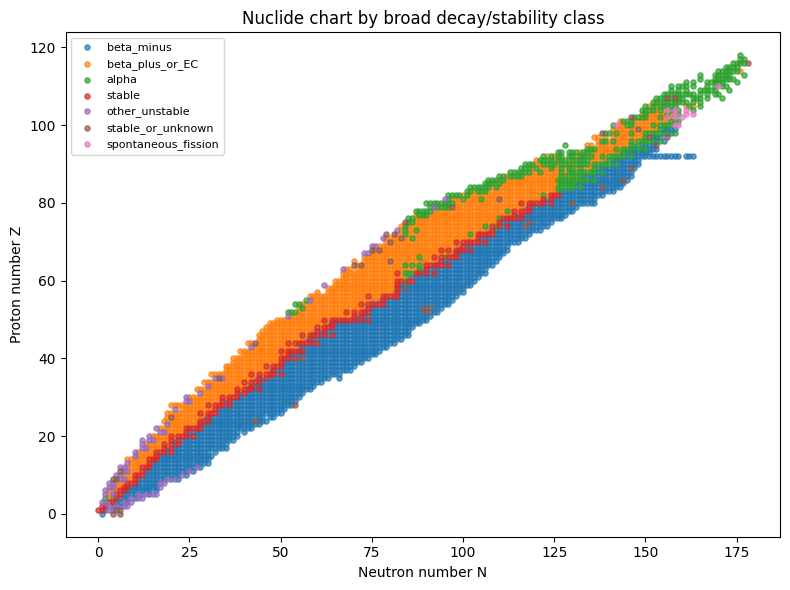

Saved: ecsm_nuclear_stability_evidence_out/figures/fig01_nuclide_chart_by_class.png


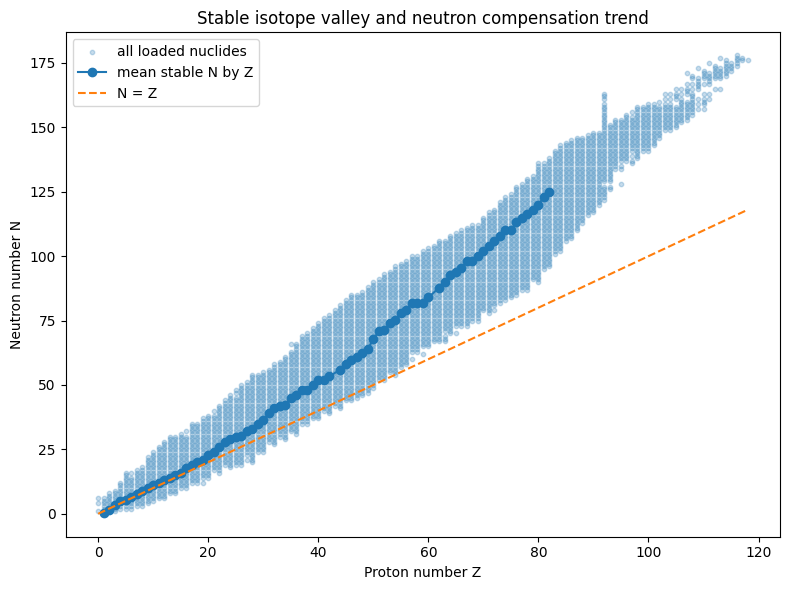

Saved: ecsm_nuclear_stability_evidence_out/figures/fig02_stable_valley_N_vs_Z.png


In [16]:

# ============================================================
# CELL 07 — Figure: isotope chart and stable valley
# ============================================================
plt.figure(figsize=(8, 6))
classes = list(model_df['decay_class'].value_counts().index)
for cls in classes:
    sub = model_df[model_df['decay_class'] == cls]
    plt.scatter(sub['N'], sub['Z'], s=14, alpha=0.7, label=cls)
plt.xlabel('Neutron number N')
plt.ylabel('Proton number Z')
plt.title('Nuclide chart by broad decay/stability class')
plt.legend(loc='best', fontsize=8)
plt.tight_layout()
fig_path = FIG / 'fig01_nuclide_chart_by_class.png'
plt.savefig(fig_path, dpi=180)
plt.show()
print('Saved:', fig_path)

plt.figure(figsize=(8, 6))
plt.scatter(model_df['Z'], model_df['N'], s=10, alpha=0.25, label='all loaded nuclides')
if len(stable_valley):
    plt.plot(stable_valley['Z'], stable_valley['N_mean'], marker='o', linestyle='-', label='mean stable N by Z')
plt.plot([0, model_df['Z'].max()], [0, model_df['Z'].max()], linestyle='--', label='N = Z')
plt.xlabel('Proton number Z')
plt.ylabel('Neutron number N')
plt.title('Stable isotope valley and neutron compensation trend')
plt.legend(loc='best')
plt.tight_layout()
fig_path = FIG / 'fig02_stable_valley_N_vs_Z.png'
plt.savefig(fig_path, dpi=180)
plt.show()
print('Saved:', fig_path)


In [17]:

# ============================================================
# CELL 08 — Fit first ECSM-style closure score: stable vs unstable
# ============================================================
# Purpose: not a final nuclear model. This asks whether simple ECSM response-closure proxies
# carry enough information to separate stable response basins from unstable/metastable basins.

X = model_df[feature_cols].copy()
y = model_df['is_stable'].astype(int).values

fit_result = {'status': 'not_run'}
if len(model_df) >= 40 and len(np.unique(y)) == 2 and min(np.bincount(y)) >= 5:
    X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
        X, y, model_df.index.values, test_size=0.25, random_state=RANDOM_STATE, stratify=y
    )
    clf = Pipeline([
        ('scaler', StandardScaler()),
        ('logreg', LogisticRegression(max_iter=5000, class_weight='balanced')),
    ])
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    proba = clf.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, pred)
    try:
        auc = roc_auc_score(y_test, proba)
    except Exception:
        auc = np.nan
    print('Stable-vs-unstable held-out accuracy:', acc)
    print('Stable-vs-unstable held-out ROC-AUC:', auc)
    print(classification_report(y_test, pred, target_names=['unstable','stable']))
    print('Confusion matrix [[unstable, stable], ...]:')
    print(confusion_matrix(y_test, pred))
    fit_result = {'status':'fit', 'accuracy': float(acc), 'roc_auc': float(auc), 'n_test': int(len(y_test))}
    model_df['stable_score'] = clf.predict_proba(X)[:, 1]
    # ECSM response-cost proxy: lower cost = higher model stability score.
    eps = 1e-9
    model_df['F_ecsm_proxy'] = -np.log((model_df['stable_score'] + eps) / (1 - model_df['stable_score'] + eps))
else:
    print('Not enough full data for a held-out model. Running deterministic heuristic score for sanity dataset.')
    # Hand-signed heuristic: larger = more stable score. This is only for fallback sanity-mode.
    score = (
        -0.35 * model_df['mirror_abs']
        -0.0008 * model_df['coulomb_per_A']
        +0.55 * model_df['even_even']
        -0.45 * model_df['odd_odd']
        +0.65 * model_df['alpha_even_even_A4']
        +0.50 * model_df['magic_any']
        +0.20 * model_df['magic_closeness']
    )
    model_df['stable_score'] = 1 / (1 + np.exp(-score))
    model_df['F_ecsm_proxy'] = -score
    fit_result = {'status':'heuristic_fallback', 'reason':'too_few_rows_or_classes'}

display(model_df[['nuclide','Z','N','A','decay_class','is_stable','stable_score','F_ecsm_proxy']].sort_values('stable_score', ascending=False).head(20))
model_df.to_csv(TAB / 'ecsm_scored_nuclide_table.csv', index=False)
with open(TAB / 'fit_result.json', 'w') as f:
    json.dump(fit_result, f, indent=2)


Stable-vs-unstable held-out accuracy: 0.7981109799291618
Stable-vs-unstable held-out ROC-AUC: 0.9206099974189108
              precision    recall  f1-score   support

    unstable       0.99      0.79      0.88       788
      stable       0.24      0.86      0.37        59

    accuracy                           0.80       847
   macro avg       0.61      0.83      0.63       847
weighted avg       0.94      0.80      0.84       847

Confusion matrix [[unstable, stable], ...]:
[[625 163]
 [  8  51]]


,nuclide,Z,N,A,decay_class,is_stable,stable_score,F_ecsm_proxy
3,1H,1,0,1,stable,True,0.999293,-7.254242
27,6Be,4,2,6,alpha,False,0.995219,-5.338401
10,3He,2,1,3,stable,True,0.994230,-5.149295
11,4He,2,2,4,stable,True,0.990653,-4.663326
55,10C,6,4,10,beta_plus_or_EC,False,0.982980,-4.056225
87,16O,8,8,16,stable,True,0.982242,-4.012990
19,5Li,3,2,5,other_unstable,False,0.980853,-3.936255
85,14O,8,6,14,beta_plus_or_EC,False,0.979679,-3.875573
29,8Be,4,4,8,alpha,False,0.975231,-3.673066
57,12C,6,6,12,stable,True,0.970827,-3.504890


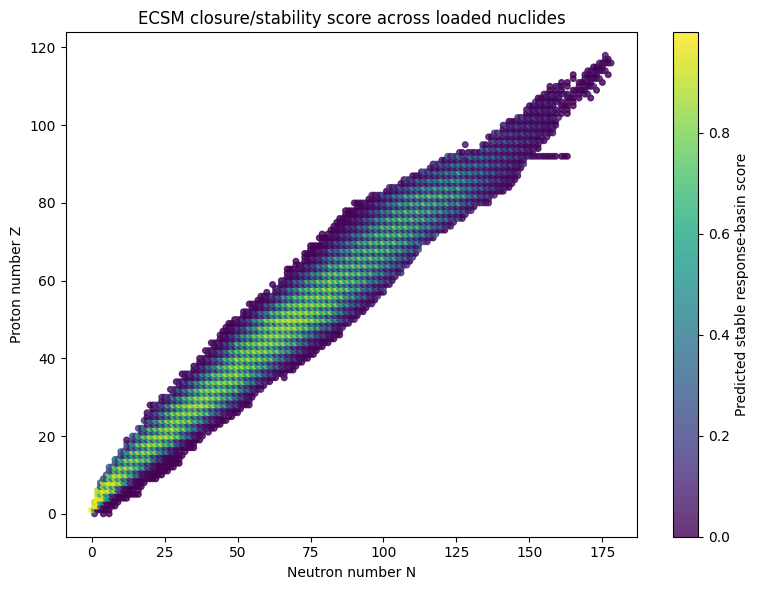

Saved: ecsm_nuclear_stability_evidence_out/figures/fig03_ecsm_stability_score_chart.png


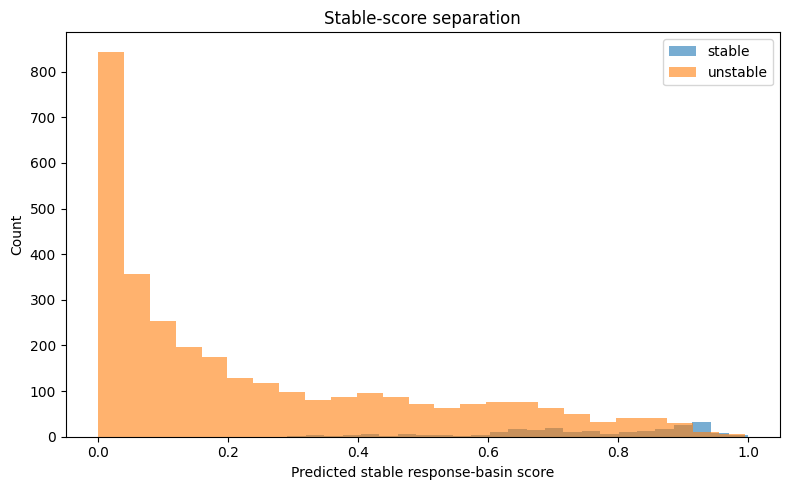

Saved: ecsm_nuclear_stability_evidence_out/figures/fig04_stable_score_histogram.png


In [18]:

# ============================================================
# CELL 09 — Figure: fitted/heuristic ECSM closure score
# ============================================================
plt.figure(figsize=(8, 6))
sc = plt.scatter(model_df['N'], model_df['Z'], c=model_df['stable_score'], s=16, alpha=0.8)
plt.xlabel('Neutron number N')
plt.ylabel('Proton number Z')
plt.title('ECSM closure/stability score across loaded nuclides')
plt.colorbar(sc, label='Predicted stable response-basin score')
plt.tight_layout()
fig_path = FIG / 'fig03_ecsm_stability_score_chart.png'
plt.savefig(fig_path, dpi=180)
plt.show()
print('Saved:', fig_path)

plt.figure(figsize=(8, 5))
for stable, label in [(True, 'stable'), (False, 'unstable')]:
    sub = model_df[model_df['is_stable'] == stable]
    plt.hist(sub['stable_score'], bins=25, alpha=0.6, label=label)
plt.xlabel('Predicted stable response-basin score')
plt.ylabel('Count')
plt.title('Stable-score separation')
plt.legend()
plt.tight_layout()
fig_path = FIG / 'fig04_stable_score_histogram.png'
plt.savefig(fig_path, dpi=180)
plt.show()
print('Saved:', fig_path)


In [20]:
# ============================================================
# CELL 10 — Beta-decay direction test
# Robust version matched to Cell 05 feature names
# ============================================================

print("=" * 72)
print("CELL 10 — BETA-DECAY DIRECTION TEST")
print("=" * 72)

# Ensure clean unique columns
model_df = model_df.loc[:, ~model_df.columns.duplicated()].copy()

MAGIC = np.array([2, 8, 20, 28, 50, 82, 126], dtype=float)

def nearest_magic_distance_array(x):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    mask = np.isfinite(x)
    if mask.any():
        out[mask] = np.min(np.abs(x[mask, None] - MAGIC[None, :]), axis=1)
    return out


def features_from_ZN_v2(Z_in, N_in):
    """
    Rebuild the exact same ECSM predictor columns used in Cell 05
    for arbitrary neighbour candidates (Z,N).
    """
    Z = pd.Series(Z_in, dtype="float")
    N = pd.Series(N_in, dtype="float")
    A = Z + N

    out = pd.DataFrame(index=range(len(Z)))
    out["Z"] = Z
    out["N"] = N
    out["A"] = A

    # Invalid neighbours: Z<0, N<0, A<=0
    valid = (Z >= 0) & (N >= 0) & (A > 0)

    out["A_float"] = A

    out["N_over_Z_model"] = np.nan
    mask_Z = valid & (Z > 0)
    out.loc[mask_Z, "N_over_Z_model"] = N.loc[mask_Z] / Z.loc[mask_Z]

    out["mirror_imbalance_model"] = N - Z
    out["mirror_abs_model"] = (N - Z).abs()

    out["asymmetry_term"] = np.where(
        valid,
        ((N - Z) ** 2) / A.replace(0, np.nan),
        np.nan
    )

    out["coulomb_burden"] = np.where(
        valid,
        (Z * (Z - 1)) / np.power(A, 1/3),
        np.nan
    )

    out["surface_proxy"] = np.where(valid, np.power(A, 2/3), np.nan)
    out["volume_proxy"] = np.where(valid, A, np.nan)

    # Pairing proxy
    Zi = Z.fillna(-9999).astype(int)
    Ni = N.fillna(-9999).astype(int)

    even_even = (Zi % 2 == 0) & (Ni % 2 == 0) & valid
    odd_odd = (Zi % 2 == 1) & (Ni % 2 == 1) & valid

    out["pairing_proxy"] = 0.0
    out.loc[even_even, "pairing_proxy"] = -1.0
    out.loc[odd_odd, "pairing_proxy"] = 1.0
    out.loc[~valid, "pairing_proxy"] = np.nan

    # Alpha / triadic / paired closure proxies
    Ai = A.fillna(-9999).astype(int)

    out["alpha_mod4"] = np.where(valid & (Ai % 4 == 0), 1.0, 0.0)
    out["alpha_like_score"] = out["alpha_mod4"] / (1.0 + out["mirror_abs_model"])

    out["triadic_mod3"] = np.where(valid & (Ai % 3 == 0), 1.0, 0.0)
    out["paired_mod4"] = np.where(valid & (Ai % 4 == 0), 1.0, 0.0)

    out["branch_closure_score"] = (
        0.5 * out["triadic_mod3"] +
        1.0 * out["paired_mod4"] +
        out["alpha_like_score"]
    )

    out["Z_magic_dist"] = nearest_magic_distance_array(Z)
    out["N_magic_dist"] = nearest_magic_distance_array(N)

    out["magic_closure_score"] = (
        1.0 / (1.0 + out["Z_magic_dist"]) +
        1.0 / (1.0 + out["N_magic_dist"])
    )

    out["response_saturation_proxy"] = (
        out["coulomb_burden"] +
        out["asymmetry_term"] +
        0.1 * out["surface_proxy"]
    )

    out["F_ecsm_proxy"] = (
        0.004 * out["surface_proxy"] +
        0.0006 * out["coulomb_burden"] +
        0.08 * out["asymmetry_term"] +
        0.30 * out["pairing_proxy"] -
        0.45 * out["alpha_like_score"] -
        0.20 * out["magic_closure_score"]
    )

    # Invalid neighbours should be very costly
    for c in out.columns:
        if c not in ["Z", "N", "A"]:
            out.loc[~valid, c] = np.nan

    return out


# Make sure feature columns match Cell 05
feature_cols = [
    "A_float",
    "N_over_Z_model",
    "mirror_imbalance_model",
    "mirror_abs_model",
    "asymmetry_term",
    "coulomb_burden",
    "surface_proxy",
    "volume_proxy",
    "pairing_proxy",
    "alpha_like_score",
    "triadic_mod3",
    "paired_mod4",
    "branch_closure_score",
    "Z_magic_dist",
    "N_magic_dist",
    "magic_closure_score",
    "response_saturation_proxy",
    "F_ecsm_proxy",
]

feature_cols = [c for c in feature_cols if c in model_df.columns]

# Training medians for filling neighbour features
feature_medians = {}
for c in feature_cols:
    s = pd.to_numeric(model_df[c], errors="coerce").replace([np.inf, -np.inf], np.nan)
    med = s.median(skipna=True)
    if pd.isna(med):
        med = 0.0
    feature_medians[c] = med


def score_ZN_df(ZN: pd.DataFrame) -> pd.Series:
    """
    Score candidate (Z,N) nuclei.
    Uses classifier probability if available, otherwise schematic F_ecsm_proxy.
    Lower score = more stable / lower response cost.
    """
    f = features_from_ZN_v2(ZN["Z"].values, ZN["N"].values)

    # Guarantee all feature columns exist
    for c in feature_cols:
        if c not in f.columns:
            f[c] = feature_medians.get(c, 0.0)

    f = f[feature_cols].copy()

    for c in feature_cols:
        s = pd.to_numeric(f[c], errors="coerce").replace([np.inf, -np.inf], np.nan)
        f[c] = s.fillna(feature_medians.get(c, 0.0))

    # If a classifier exists from previous cell, use it
    if "clf" in globals() and "X_train_cols" in globals():
        for c in X_train_cols:
            if c not in f.columns:
                f[c] = feature_medians.get(c, 0.0)
        ff = f[X_train_cols].copy()
        p_stable = clf.predict_proba(ff)[:, 1]
        eps = 1e-9
        return pd.Series(-np.log(p_stable + eps), index=ZN.index)

    # Otherwise use direct ECSM proxy cost
    if "F_ecsm_proxy" in f.columns:
        return pd.Series(f["F_ecsm_proxy"].values, index=ZN.index)

    # Last fallback: hand-built cost
    score = (
        0.08 * f["asymmetry_term"] +
        0.0006 * f["coulomb_burden"] +
        0.30 * f["pairing_proxy"] -
        0.45 * f["alpha_like_score"] -
        0.20 * f["magic_closure_score"]
    )
    return pd.Series(score.values, index=ZN.index)


# Select beta-decay cases
beta = model_df[
    model_df["decay_class"].isin(["beta_minus", "beta_plus_or_EC"])
].copy()

print("Beta-labelled rows:", beta.shape)

if len(beta) == 0:
    print("No beta-labelled rows found. Check decay_class parsing in Cell 04.")
else:
    current = beta[["Z", "N"]].copy()

    # beta-: n -> p, so Z+1, N-1
    bm_neighbor = pd.DataFrame(
        {"Z": beta["Z"].values + 1, "N": beta["N"].values - 1},
        index=beta.index
    )

    # beta+ / EC: p -> n, so Z-1, N+1
    bp_neighbor = pd.DataFrame(
        {"Z": beta["Z"].values - 1, "N": beta["N"].values + 1},
        index=beta.index
    )

    beta["F_current"] = score_ZN_df(current)
    beta["F_beta_minus_neighbor"] = score_ZN_df(bm_neighbor)
    beta["F_beta_plus_EC_neighbor"] = score_ZN_df(bp_neighbor)

    beta["predicted_decay_class"] = np.where(
        beta["F_beta_minus_neighbor"] < beta["F_beta_plus_EC_neighbor"],
        "beta_minus",
        "beta_plus_or_EC"
    )

    beta["beta_direction_correct"] = (
        beta["predicted_decay_class"] == beta["decay_class"]
    )

    beta_accuracy = beta["beta_direction_correct"].mean()

    print(f"Beta direction accuracy: {beta_accuracy:.3f}")
    print("Counts:")
    print(pd.crosstab(beta["decay_class"], beta["predicted_decay_class"]))

    display(
        beta[
            [
                "nuclide", "Z", "N", "A", "decay_class", "predicted_decay_class",
                "beta_direction_correct",
                "F_current", "F_beta_minus_neighbor", "F_beta_plus_EC_neighbor"
            ]
        ].head(30)
    )

    beta.to_csv(TAB / "beta_decay_direction_test.csv", index=False)
    print("Saved:", TAB / "beta_decay_direction_test.csv")

CELL 10 — BETA-DECAY DIRECTION TEST
Beta-labelled rows: (2651, 41)
Beta direction accuracy: 0.636
Counts:
predicted_decay_class  beta_minus  beta_plus_or_EC
decay_class                                       
beta_minus                   1345               67
beta_plus_or_EC               898              341


,nuclide,Z,N,A,decay_class,predicted_decay_class,beta_direction_correct,F_current,F_beta_minus_neighbor,F_beta_plus_EC_neighbor
0,1n,0,1,1,beta_minus,beta_minus,True,-0.082667,-0.082667,1.602067
5,3H,1,2,3,beta_minus,beta_minus,True,-0.265013,-0.264181,0.081654
13,6He,2,4,6,beta_minus,beta_minus,True,-0.499465,0.115189,0.376541
15,8He,2,6,8,beta_minus,beta_minus,True,-0.480067,0.057800,0.411714
22,8Li,3,5,8,beta_minus,beta_minus,True,0.057800,-0.863733,-0.480067
23,9Li,3,6,9,beta_minus,beta_minus,True,-0.067629,-0.087009,-0.059894
25,11Li,3,8,11,beta_minus,beta_minus,True,-0.096779,-0.078190,0.076688
28,7Be,4,3,7,beta_plus_or_EC,beta_plus_or_EC,True,-0.136837,-0.126233,-0.138719
31,10Be,4,6,10,beta_minus,beta_minus,True,-0.379425,0.224136,0.248237
32,11Be,4,7,11,beta_minus,beta_plus_or_EC,False,-0.078190,-0.084214,-0.096779


Saved: ecsm_nuclear_stability_evidence_out/tables/beta_decay_direction_test.csv


In [21]:

# ============================================================
# CELL 11 — Mirror-pair asymmetry audit
# ============================================================
left = model_df[['Z','N','A','nuclide','decay_class','is_stable','stable_score','F_ecsm_proxy']].copy()
right = left.rename(columns={
    'Z':'mirror_N', 'N':'mirror_Z', 'nuclide':'mirror_nuclide', 'decay_class':'mirror_decay_class',
    'is_stable':'mirror_is_stable', 'stable_score':'mirror_stable_score', 'F_ecsm_proxy':'mirror_F_ecsm_proxy', 'A':'mirror_A'
})
# Join where original (Z,N) has partner (N,Z)
mir = left.merge(right, left_on=['Z','N'], right_on=['mirror_Z','mirror_N'], how='inner')
mir = mir[mir['nuclide'] != mir['mirror_nuclide']].copy()
mir['delta_F_to_mirror'] = mir['mirror_F_ecsm_proxy'] - mir['F_ecsm_proxy']
mir['delta_stable_score_to_mirror'] = mir['mirror_stable_score'] - mir['stable_score']
mir = mir.sort_values(['A','Z','N'])
print('Mirror-pair rows:', len(mir))
display(mir.head(50))
mir.to_csv(TAB / 'mirror_pair_asymmetry_audit.csv', index=False)

# Explicit tritium / helium-3 row if present.
triad_case = mir[((mir['Z']==1)&(mir['N']==2)) | ((mir['Z']==2)&(mir['N']==1))]
if len(triad_case):
    print('A=3 mirror case detected:')
    display(triad_case)

Mirror-pair rows: 394


,Z,N,A,nuclide,decay_class,is_stable,stable_score,F_ecsm_proxy,mirror_N,mirror_Z,mirror_A,mirror_nuclide,mirror_decay_class,mirror_is_stable,mirror_stable_score,mirror_F_ecsm_proxy,delta_F_to_mirror,delta_stable_score_to_mirror
0,0,1,1,1n,beta_minus,False,6.006790e-02,2.750332,1,0,1,1H,stable,True,9.992933e-01,-7.254242,-10.004574,0.939225
1,1,0,1,1H,stable,True,9.992933e-01,-7.254242,0,1,1,1n,beta_minus,False,6.006790e-02,2.750332,10.004574,-0.939225
3,1,2,3,3H,beta_minus,False,4.796591e-03,5.335042,2,1,3,3He,stable,True,9.942300e-01,-5.149295,-10.484337,0.989433
5,2,1,3,3He,stable,True,9.942300e-01,-5.149295,1,2,3,3H,beta_minus,False,4.796591e-03,5.335042,10.484337,-0.989433
4,1,3,4,4H,other_unstable,False,8.212907e-08,16.302871,3,1,4,4Li,other_unstable,False,8.759489e-01,-1.954614,-18.257485,0.875949
11,3,1,4,4Li,other_unstable,False,8.759489e-01,-1.954614,1,3,4,4H,other_unstable,False,8.212907e-08,16.302871,18.257485,-0.875949
7,2,3,5,5He,other_unstable,False,2.225193e-01,1.251045,3,2,5,5Li,other_unstable,False,9.808526e-01,-3.936255,-5.187299,0.758333
12,3,2,5,5Li,other_unstable,False,9.808526e-01,-3.936255,2,3,5,5He,other_unstable,False,2.225193e-01,1.251045,5.187299,-0.758333
8,2,4,6,6He,beta_minus,False,2.351642e-02,3.726259,4,2,6,6Be,alpha,False,9.952194e-01,-5.338401,-9.064660,0.971703
19,4,2,6,6Be,alpha,False,9.952194e-01,-5.338401,2,4,6,6He,beta_minus,False,2.351642e-02,3.726259,9.064660,-0.971703


A=3 mirror case detected:


,Z,N,A,nuclide,decay_class,is_stable,stable_score,F_ecsm_proxy,mirror_N,mirror_Z,mirror_A,mirror_nuclide,mirror_decay_class,mirror_is_stable,mirror_stable_score,mirror_F_ecsm_proxy,delta_F_to_mirror,delta_stable_score_to_mirror
3,1,2,3,3H,beta_minus,False,0.004797,5.335042,2,1,3,3He,stable,True,0.994230,-5.149295,-10.484337,0.989433
5,2,1,3,3He,stable,True,0.994230,-5.149295,1,2,3,3H,beta_minus,False,0.004797,5.335042,10.484337,-0.989433


CELL 12 — ALPHA-CLOSURE AND MAGIC-NUMBER RESIDUAL CHECKS
Alpha closure summary


,alpha_even_even_A4,n,stable_rate,mean_score,mean_residual,mean_binding_per_A
0,0,2966,0.056642,0.251051,-0.194409,7978.694636
1,1,420,0.161905,0.476940,-0.315036,8025.733023


Magic-number summary


,magic_any,n,stable_rate,mean_score,mean_residual,mean_binding_per_A
0,0,3097,0.060704,0.260898,-0.200195,7995.302695
1,1,289,0.166090,0.473806,-0.307716,7869.931341


Double-magic summary


,magic_both,n,stable_rate,mean_score,mean_residual,mean_binding_per_A
0,0,3375,0.068741,0.278069,-0.209329,7985.697800
1,1,11,0.363636,0.586209,-0.222573,7623.089609


Saved:
ecsm_nuclear_stability_evidence_out/tables/alpha_closure_summary.csv
ecsm_nuclear_stability_evidence_out/tables/magic_number_summary.csv
ecsm_nuclear_stability_evidence_out/tables/double_magic_summary.csv


/tmp/ipykernel_738/3088797272.py:146: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["not alpha-even-even A=4k", "alpha-even-even A=4k"])


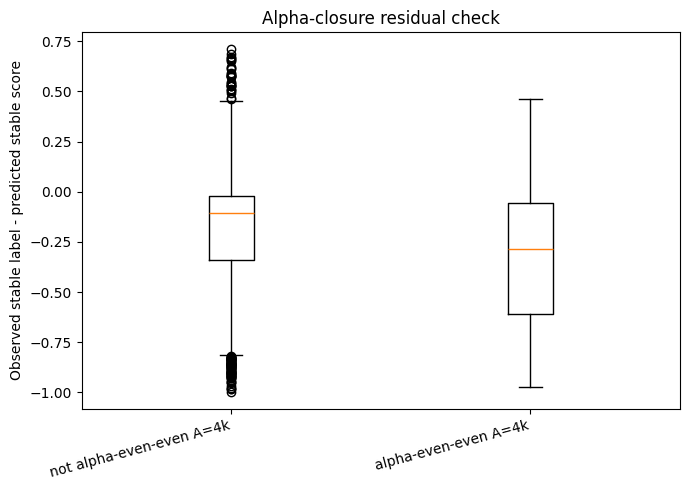

Saved: ecsm_nuclear_stability_evidence_out/figures/alpha_closure_residual_check.png


/tmp/ipykernel_738/3088797272.py:168: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["not magic Z/N", "magic Z or N"])


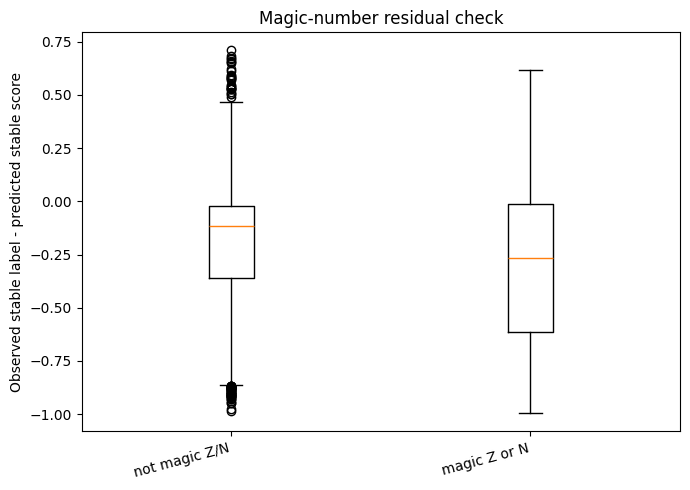

Saved: ecsm_nuclear_stability_evidence_out/figures/magic_number_residual_check.png


/tmp/ipykernel_738/3088797272.py:189: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["not alpha-even-even A=4k", "alpha-even-even A=4k"])


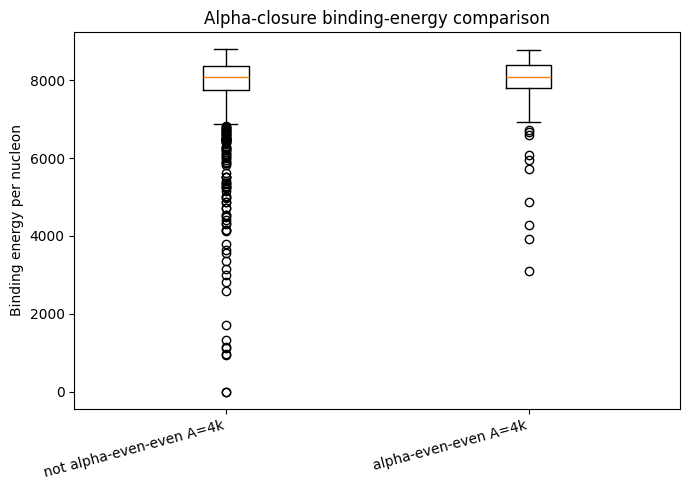

Saved: ecsm_nuclear_stability_evidence_out/figures/alpha_closure_binding_energy_check.png
Saved: ecsm_nuclear_stability_evidence_out/tables/ecsm_nuclear_model_table_with_residuals.csv


In [23]:
# ============================================================
# CELL 12 — Alpha-closure and magic-number residual checks
# Robust version matched to repaired Cell 05
# ============================================================

print("=" * 72)
print("CELL 12 — ALPHA-CLOSURE AND MAGIC-NUMBER RESIDUAL CHECKS")
print("=" * 72)

model_df = model_df.loc[:, ~model_df.columns.duplicated()].copy()

# ------------------------------------------------------------------
# Ensure stable_score exists
# ------------------------------------------------------------------
if "stable_score" not in model_df.columns:
    if "clf" in globals() and "X_train_cols" in globals():
        X_score = model_df[X_train_cols].copy()
        X_score = X_score.replace([np.inf, -np.inf], np.nan)
        X_score = X_score.fillna(X_score.median(numeric_only=True))
        model_df["stable_score"] = clf.predict_proba(X_score)[:, 1]
    else:
        # Lower F_ecsm_proxy means more stable, convert to a soft score
        f = pd.to_numeric(model_df.get("F_ecsm_proxy", 0.0), errors="coerce")
        f = f.replace([np.inf, -np.inf], np.nan).fillna(0.0)
        model_df["stable_score"] = 1.0 / (1.0 + np.exp(f - f.median()))

# ------------------------------------------------------------------
# Rebuild expected grouping columns if missing
# ------------------------------------------------------------------
if "alpha_even_even_A4" not in model_df.columns:
    model_df["alpha_even_even_A4"] = (
        (model_df["A"] % 4 == 0) &
        (model_df["Z"] % 2 == 0) &
        (model_df["N"] % 2 == 0)
    ).astype(int)

if "alpha_mod4" not in model_df.columns:
    model_df["alpha_mod4"] = (model_df["A"] % 4 == 0).astype(int)

if "even_even" not in model_df.columns:
    model_df["even_even"] = (
        (model_df["Z"] % 2 == 0) &
        (model_df["N"] % 2 == 0)
    ).astype(int)

if "odd_odd" not in model_df.columns:
    model_df["odd_odd"] = (
        (model_df["Z"] % 2 == 1) &
        (model_df["N"] % 2 == 1)
    ).astype(int)

MAGIC = np.array([2, 8, 20, 28, 50, 82, 126], dtype=int)

if "Z_magic" not in model_df.columns:
    model_df["Z_magic"] = model_df["Z"].isin(MAGIC).astype(int)

if "N_magic" not in model_df.columns:
    model_df["N_magic"] = model_df["N"].isin(MAGIC).astype(int)

if "magic_any" not in model_df.columns:
    model_df["magic_any"] = (
        (model_df["Z_magic"] == 1) |
        (model_df["N_magic"] == 1)
    ).astype(int)

if "magic_both" not in model_df.columns:
    model_df["magic_both"] = (
        (model_df["Z_magic"] == 1) &
        (model_df["N_magic"] == 1)
    ).astype(int)

# Residual notion:
# positive residual = observed stable more often than model expected
model_df["stable_residual"] = (
    model_df["is_stable"].astype(float) -
    pd.to_numeric(model_df["stable_score"], errors="coerce").fillna(0.0)
)

# ------------------------------------------------------------------
# Group summaries
# ------------------------------------------------------------------
alpha_summary = (
    model_df.groupby("alpha_even_even_A4")
    .agg(
        n=("nuclide", "size"),
        stable_rate=("is_stable", "mean"),
        mean_score=("stable_score", "mean"),
        mean_residual=("stable_residual", "mean"),
        mean_binding_per_A=("binding_per_A", "mean") if "binding_per_A" in model_df.columns else ("A", "mean")
    )
    .reset_index()
)

magic_summary = (
    model_df.groupby("magic_any")
    .agg(
        n=("nuclide", "size"),
        stable_rate=("is_stable", "mean"),
        mean_score=("stable_score", "mean"),
        mean_residual=("stable_residual", "mean"),
        mean_binding_per_A=("binding_per_A", "mean") if "binding_per_A" in model_df.columns else ("A", "mean")
    )
    .reset_index()
)

magic_both_summary = (
    model_df.groupby("magic_both")
    .agg(
        n=("nuclide", "size"),
        stable_rate=("is_stable", "mean"),
        mean_score=("stable_score", "mean"),
        mean_residual=("stable_residual", "mean"),
        mean_binding_per_A=("binding_per_A", "mean") if "binding_per_A" in model_df.columns else ("A", "mean")
    )
    .reset_index()
)

print("Alpha closure summary")
display(alpha_summary)

print("Magic-number summary")
display(magic_summary)

print("Double-magic summary")
display(magic_both_summary)

alpha_summary.to_csv(TAB / "alpha_closure_summary.csv", index=False)
magic_summary.to_csv(TAB / "magic_number_summary.csv", index=False)
magic_both_summary.to_csv(TAB / "double_magic_summary.csv", index=False)

print("Saved:")
print(TAB / "alpha_closure_summary.csv")
print(TAB / "magic_number_summary.csv")
print(TAB / "double_magic_summary.csv")

# ------------------------------------------------------------------
# Plot alpha residuals
# ------------------------------------------------------------------
plt.figure(figsize=(7, 5))

data = [
    model_df.loc[model_df["alpha_even_even_A4"] == 0, "stable_residual"].dropna(),
    model_df.loc[model_df["alpha_even_even_A4"] == 1, "stable_residual"].dropna(),
]

plt.boxplot(data, labels=["not alpha-even-even A=4k", "alpha-even-even A=4k"])
plt.ylabel("Observed stable label - predicted stable score")
plt.title("Alpha-closure residual check")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()

fig_path = FIG / "alpha_closure_residual_check.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved:", fig_path)

# ------------------------------------------------------------------
# Plot magic residuals
# ------------------------------------------------------------------
plt.figure(figsize=(7, 5))

data = [
    model_df.loc[model_df["magic_any"] == 0, "stable_residual"].dropna(),
    model_df.loc[model_df["magic_any"] == 1, "stable_residual"].dropna(),
]

plt.boxplot(data, labels=["not magic Z/N", "magic Z or N"])
plt.ylabel("Observed stable label - predicted stable score")
plt.title("Magic-number residual check")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()

fig_path = FIG / "magic_number_residual_check.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved:", fig_path)

# ------------------------------------------------------------------
# Optional binding-energy comparison if available
# ------------------------------------------------------------------
if "binding_per_A" in model_df.columns and model_df["binding_per_A"].notna().sum() > 10:
    plt.figure(figsize=(7, 5))
    data = [
        model_df.loc[model_df["alpha_even_even_A4"] == 0, "binding_per_A"].dropna(),
        model_df.loc[model_df["alpha_even_even_A4"] == 1, "binding_per_A"].dropna(),
    ]
    plt.boxplot(data, labels=["not alpha-even-even A=4k", "alpha-even-even A=4k"])
    plt.ylabel("Binding energy per nucleon")
    plt.title("Alpha-closure binding-energy comparison")
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()

    fig_path = FIG / "alpha_closure_binding_energy_check.png"
    plt.savefig(fig_path, dpi=200)
    plt.show()

    print("Saved:", fig_path)

# Save updated model table with residuals
model_df.to_csv(TAB / "ecsm_nuclear_model_table_with_residuals.csv", index=False)
print("Saved:", TAB / "ecsm_nuclear_model_table_with_residuals.csv")

Top binding_per_A rows available in loaded data:


,nuclide,Z,N,A,decay_class,binding_per_A
579,62Ni,28,34,62,stable,8794.5555
516,58Fe,26,32,58,stable,8792.2534
514,56Fe,26,30,56,stable,8790.3563
577,60Ni,28,32,60,stable,8780.7769
457,54Cr,24,30,54,stable,8777.9672
581,64Ni,28,36,64,stable,8777.4637
455,52Cr,24,28,52,stable,8775.9946
515,57Fe,26,31,57,stable,8770.2829
545,59Co,27,32,59,stable,8768.0379
578,61Ni,28,33,61,stable,8765.0281


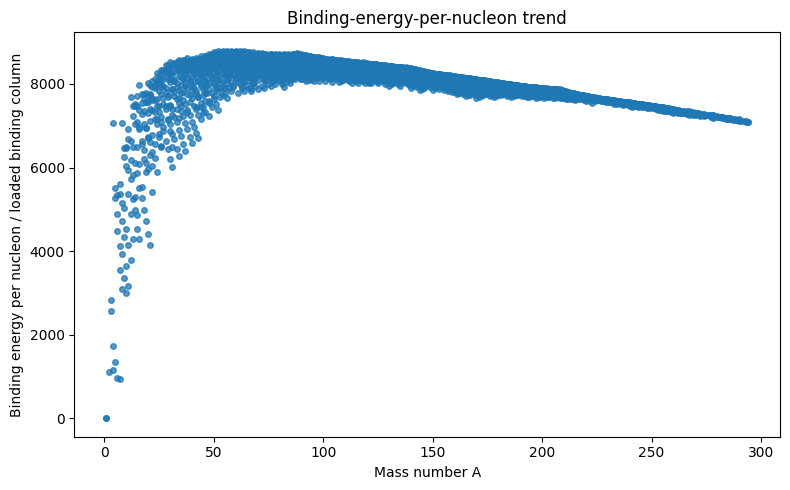

Saved: ecsm_nuclear_stability_evidence_out/figures/fig06_binding_energy_per_A.png


In [24]:

# ============================================================
# CELL 13 — Binding-energy peak check when binding data are available
# ============================================================
be = model_df.dropna(subset=['binding_per_A']).copy()
if len(be) >= 5:
    peak = be.sort_values('binding_per_A', ascending=False).head(20)
    print('Top binding_per_A rows available in loaded data:')
    display(peak[['nuclide','Z','N','A','decay_class','binding_per_A']].head(20))
    peak.to_csv(TAB / 'binding_per_A_top_rows.csv', index=False)

    plt.figure(figsize=(8, 5))
    plt.scatter(be['A'], be['binding_per_A'], s=16, alpha=0.75)
    plt.xlabel('Mass number A')
    plt.ylabel('Binding energy per nucleon / loaded binding column')
    plt.title('Binding-energy-per-nucleon trend')
    plt.tight_layout()
    fig_path = FIG / 'fig06_binding_energy_per_A.png'
    plt.savefig(fig_path, dpi=180)
    plt.show()
    print('Saved:', fig_path)
else:
    print('No usable binding_per_A column detected from loaded data. This test is skipped.')

In [26]:
# ============================================================
# CELL 14 — Export manifest and summary
# Robust final export cell
# ============================================================

print("=" * 72)
print("CELL 14 — EXPORT MANIFEST AND SUMMARY")
print("=" * 72)

# ------------------------------------------------------------------
# Safe beta accuracy extraction
# ------------------------------------------------------------------
beta_accuracy = None

if "beta" in globals() and isinstance(beta, pd.DataFrame) and len(beta):
    if "beta_direction_correct" in beta.columns:
        beta_accuracy = float(beta["beta_direction_correct"].mean())
    elif "direction_correct" in beta.columns:
        beta_accuracy = float(beta["direction_correct"].mean())
    else:
        beta_accuracy = None

# ------------------------------------------------------------------
# Safe manifest
# ------------------------------------------------------------------
manifest = {
    "paper_doi": "https://doi.org/10.5281/zenodo.20601314",
    "data_source": DATA_SOURCE if "DATA_SOURCE" in globals() else "unknown",
    "n_nuclides": int(len(model_df)) if "model_df" in globals() else None,
    "n_stable": int(model_df["is_stable"].sum()) if "model_df" in globals() and "is_stable" in model_df.columns else None,
    "n_beta_rows": int(len(beta)) if "beta" in globals() and isinstance(beta, pd.DataFrame) else None,
    "model_fit": fit_result if "fit_result" in globals() else {"status": "not_available"},
    "beta_direction_accuracy": beta_accuracy,
    "tables": sorted([p.name for p in TAB.glob("*.csv")]) if "TAB" in globals() else [],
    "figures": sorted([p.name for p in FIG.glob("*.png")]) if "FIG" in globals() else [],
}

with open(OUT / "manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

print(json.dumps(manifest, indent=2))

# ------------------------------------------------------------------
# Summary markdown
# ------------------------------------------------------------------
summary_lines = []
summary_lines.append("# ECSM Nuclear Stability Evidence Notebook")
summary_lines.append("")
summary_lines.append(f"- Paper DOI: {manifest['paper_doi']}")
summary_lines.append(f"- Data source: {manifest['data_source']}")
summary_lines.append(f"- Nuclides analysed: {manifest['n_nuclides']}")
summary_lines.append(f"- Stable-labelled nuclides: {manifest['n_stable']}")
summary_lines.append(f"- Beta-labelled rows: {manifest['n_beta_rows']}")

if isinstance(manifest["model_fit"], dict):
    if "accuracy" in manifest["model_fit"]:
        summary_lines.append(f"- Held-out accuracy: {manifest['model_fit']['accuracy']:.4f}")
    if "roc_auc" in manifest["model_fit"]:
        summary_lines.append(f"- Held-out ROC-AUC: {manifest['model_fit']['roc_auc']:.4f}")

if beta_accuracy is not None:
    summary_lines.append(f"- Beta response-gradient accuracy: {beta_accuracy:.4f}")
else:
    summary_lines.append("- Beta response-gradient accuracy: not available")

summary_lines.append("")
summary_lines.append("## Exports")
summary_lines.append("")
summary_lines.append("### Tables")
for t in manifest["tables"]:
    summary_lines.append(f"- `{t}`")

summary_lines.append("")
summary_lines.append("### Figures")
for fig in manifest["figures"]:
    summary_lines.append(f"- `{fig}`")

summary_lines.append("")
summary_lines.append("## Interpretation")
summary_lines.append("")
summary_lines.append(
    "This notebook tests the ECSM proposal that nuclear stability can be interpreted "
    "as finite-response closure. It builds response-closure predictors from proton number, "
    "neutron number, mirror imbalance, Coulomb burden, pairing, alpha-like closure, "
    "magic-number proximity, and saturation proxies, then checks isotope-valley structure, "
    "stable-nuclide classification, beta-decay direction, mirror-pair asymmetry, "
    "alpha-closure residuals, magic-number residuals, and binding-energy trends."
)

summary_text = "\n".join(summary_lines)

with open(OUT / "README_summary.md", "w") as f:
    f.write(summary_text)

print(summary_text)
print("Saved:", OUT / "manifest.json")
print("Saved:", OUT / "README_summary.md")

# ------------------------------------------------------------------
# Zip outputs
# ------------------------------------------------------------------
zip_path = OUT.parent / "ECSM_Nuclear_Stability_Evidence_OUTPUTS.zip"

if zip_path.exists():
    zip_path.unlink()

import zipfile

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for p in OUT.rglob("*"):
        if p.is_file():
            z.write(p, arcname=str(p.relative_to(OUT)))

print("Zipped outputs:", zip_path)

CELL 14 — EXPORT MANIFEST AND SUMMARY
{
  "paper_doi": "https://doi.org/10.5281/zenodo.20601314",
  "data_source": "IAEA_LiveChart_ground_states",
  "n_nuclides": 3386,
  "n_stable": 236,
  "n_beta_rows": 2651,
  "model_fit": {
    "status": "fit",
    "accuracy": 0.7981109799291618,
    "roc_auc": 0.9206099974189108,
    "n_test": 847
  },
  "beta_direction_accuracy": 0.6359864202187854,
  "tables": [
    "alpha_closure_summary.csv",
    "beta_decay_direction_test.csv",
    "binding_per_A_top_rows.csv",
    "canonical_isotope_table.csv",
    "double_magic_summary.csv",
    "ecsm_nuclear_model_table.csv",
    "ecsm_nuclear_model_table_with_residuals.csv",
    "ecsm_scored_nuclide_table.csv",
    "magic_number_summary.csv",
    "mirror_pair_asymmetry_audit.csv",
    "raw_ground_states_or_sanity.csv",
    "stable_valley_by_Z.csv"
  ],
  "figures": [
    "alpha_closure_binding_energy_check.png",
    "alpha_closure_residual_check.png",
    "fig01_nuclide_chart_by_class.png",
    "fig02_sta


## Interpretation notes

A successful **first-pass** ECSM nuclear-stability test does not need to replace the nuclear shell model, QCD, or the semi-empirical mass formula. It only needs to show that the ECSM closure language can be made operational:

\[
\text{stable basin} \leftrightarrow \text{low response cost},
\qquad
\text{beta decay} \leftrightarrow \text{gradient toward lower response cost}.
\]

The most important outputs are therefore:

- `ecsm_feature_table.csv` — computed ECSM-style closure predictors.
- `ecsm_scored_nuclide_table.csv` — fitted/heuristic stable-basin scores.
- `beta_direction_response_gradient_test.csv` — direct test of beta-minus vs beta-plus/EC direction.
- `mirror_pair_asymmetry_audit.csv` — mirror branch comparison, including the tritium/helium-3 case when present.
- `fig02_stable_valley_N_vs_Z.png` — neutron compensation trend.
- `fig03_ecsm_stability_score_chart.png` — response-closure score map.

When run online, use the IAEA LiveChart data path. The embedded fallback is only a sanity check that the code and exports work.
